# Flight Delay Prediction — Results


## 1. Imports


In [31]:
# AI generated:
from pathlib import Path
import sys

import df_compare

project_root = Path.cwd()
if not (project_root / "src").exists() and (project_root.parent / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import FINAL_DATASET_PATH, RESULTS_DIR
from src.baseline import main as run_baseline
from src.random_forest import main as run_rf
from src.XGBoost import main as run_xgb

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image

## 2. Load the prepared dataset

In [32]:
df = pd.read_csv(FINAL_DATASET_PATH)
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 35,358 rows x 18 columns


,month,day,origin,dest,carrier,route,dep_delay,distance,great_circle_km,origin_lat,origin_lon,dest_lat,dest_lon,TMAX,PRCP,dep_hour,is_weekend,arr_delay
0,1,1,PDX,ANC,AS,PDX_ANC,96.0,1542,2476.733142,45.588699,-122.598000,61.174400,-149.996002,72.0,0.0,0,0,70.0
1,1,1,SEA,CLT,US,SEA_CLT,-6.0,2279,3660.405629,47.449001,-122.308998,35.214001,-80.943100,72.0,0.0,0,0,-23.0
2,1,1,PDX,IAH,UA,PDX_IAH,13.0,1825,2933.724167,45.588699,-122.598000,29.984400,-95.341400,72.0,0.0,0,0,-4.0
3,1,1,PDX,CLT,US,PDX_CLT,-2.0,2282,3664.493683,45.588699,-122.598000,35.214001,-80.943100,72.0,0.0,0,0,-23.0
4,1,1,SEA,ANC,AS,SEA_ANC,44.0,1448,2325.640446,47.449001,-122.308998,61.174400,-149.996002,72.0,0.0,0,0,43.0


In [33]:
df.info()
display(df.select_dtypes(include="number").describe())

<class 'pandas.DataFrame'>
RangeIndex: 35358 entries, 0 to 35357
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   month            35358 non-null  int64  
 1   day              35358 non-null  int64  
 2   origin           35358 non-null  str    
 3   dest             35358 non-null  str    
 4   carrier          35358 non-null  str    
 5   route            35358 non-null  str    
 6   dep_delay        35358 non-null  float64
 7   distance         35358 non-null  int64  
 8   great_circle_km  35358 non-null  float64
 9   origin_lat       35358 non-null  float64
 10  origin_lon       35358 non-null  float64
 11  dest_lat         35358 non-null  float64
 12  dest_lon         35358 non-null  float64
 13  TMAX             35358 non-null  float64
 14  PRCP             35358 non-null  float64
 15  dep_hour         35358 non-null  int64  
 16  is_weekend       35358 non-null  int64  
 17  arr_delay        35358 

,month,day,dep_delay,distance,great_circle_km,origin_lat,origin_lon,dest_lat,dest_lon,TMAX,PRCP,dep_hour,is_weekend,arr_delay
count,35358.000000,35358.000000,35358.000000,35358.000000,35358.000000,35358.000000,35358.000000,35358.000000,35358.000000,35358.000000,35358.000000,35358.000000,35358.000000,35358.000000
mean,2.026896,15.634142,6.246931,1175.817665,1890.544938,46.784390,-122.412247,38.004285,-112.574299,103.918576,53.984247,12.358872,0.270038,1.194779
std,0.835502,8.721650,26.170456,653.639321,1049.437307,0.891455,0.138489,7.583946,19.167507,35.142328,87.539213,5.156430,0.443985,28.667694
min,1.000000,1.000000,-37.000000,106.000000,169.840445,45.588699,-122.598000,19.738783,-159.339005,-16.000000,0.000000,0.000000,0.000000,-62.000000
25%,1.000000,8.000000,-5.000000,689.000000,1106.714501,45.588699,-122.598000,33.817699,-122.221001,83.000000,0.000000,8.000000,0.000000,-13.000000
50%,2.000000,16.000000,-2.000000,978.000000,1576.099851,47.449001,-122.308998,37.618999,-117.190002,106.000000,5.000000,12.000000,0.000000,-5.000000
75%,3.000000,23.000000,5.000000,1616.000000,2597.050924,47.449001,-122.308998,40.692501,-97.669899,128.000000,81.000000,17.000000,1.000000,6.000000
max,3.000000,31.000000,298.000000,2724.000000,4379.461985,47.449001,-122.308998,64.815102,-71.005203,189.000000,467.000000,24.000000,1.000000,299.000000


In [34]:
# AI generated:
missing = df.isna().sum().sort_values(ascending=False)
display(missing.to_frame("missing_count"))

,missing_count
month,0
day,0
origin,0
dest,0
carrier,0
route,0
dep_delay,0
distance,0
great_circle_km,0
origin_lat,0


## 3. Exploratory Data Analysis

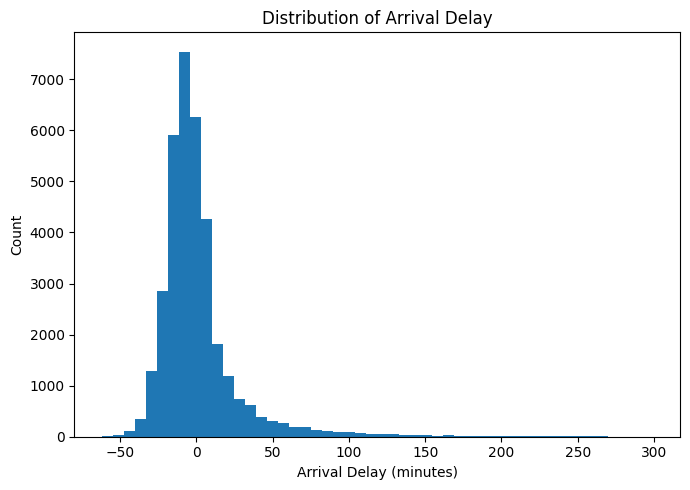

In [35]:
plt.figure(figsize=(7, 5))
plt.hist(df["arr_delay"], bins=50)
plt.title("Distribution of Arrival Delay")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

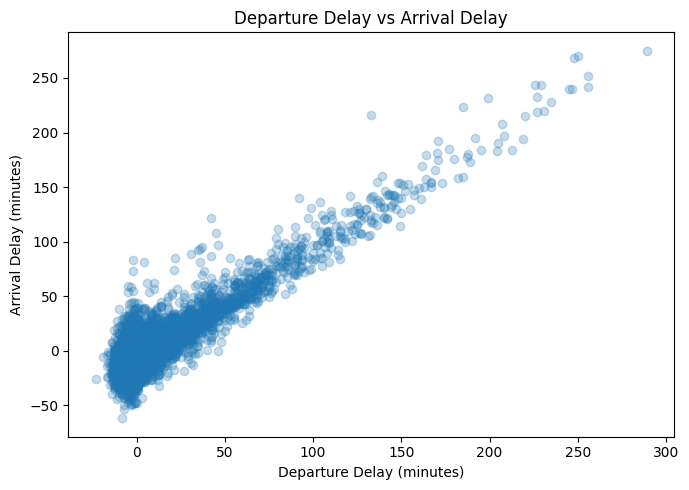

In [36]:
sample = df[['dep_delay', 'arr_delay']].dropna()
if len(sample) > 8000:
    sample = sample.sample(8000, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(sample['dep_delay'], sample['arr_delay'], alpha=0.25)
plt.title('Departure Delay vs Arrival Delay')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Arrival Delay (minutes)')
plt.tight_layout()
plt.show()

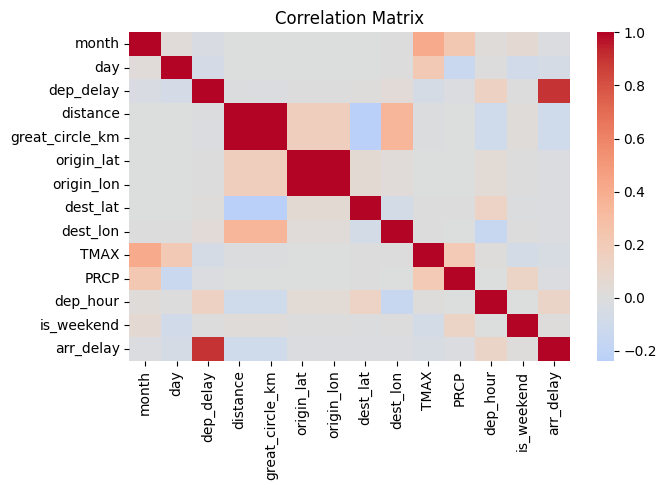

In [37]:
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

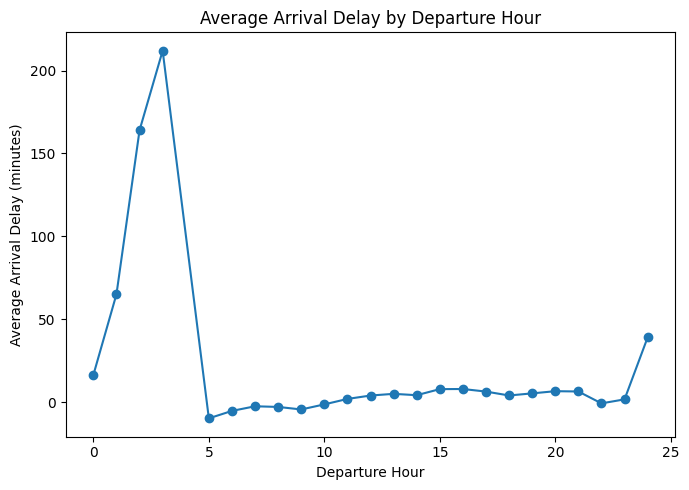

In [38]:
# AI generated:
hourly = df.groupby('dep_hour')['arr_delay'].mean().reset_index().sort_values('dep_hour')
plt.figure(figsize=(7,5))
plt.plot(hourly['dep_hour'], hourly['arr_delay'], marker='o')
plt.title('Average Arrival Delay by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Average Arrival Delay (minutes)')
plt.tight_layout()
plt.show()

## 5. Model Results

Baseline


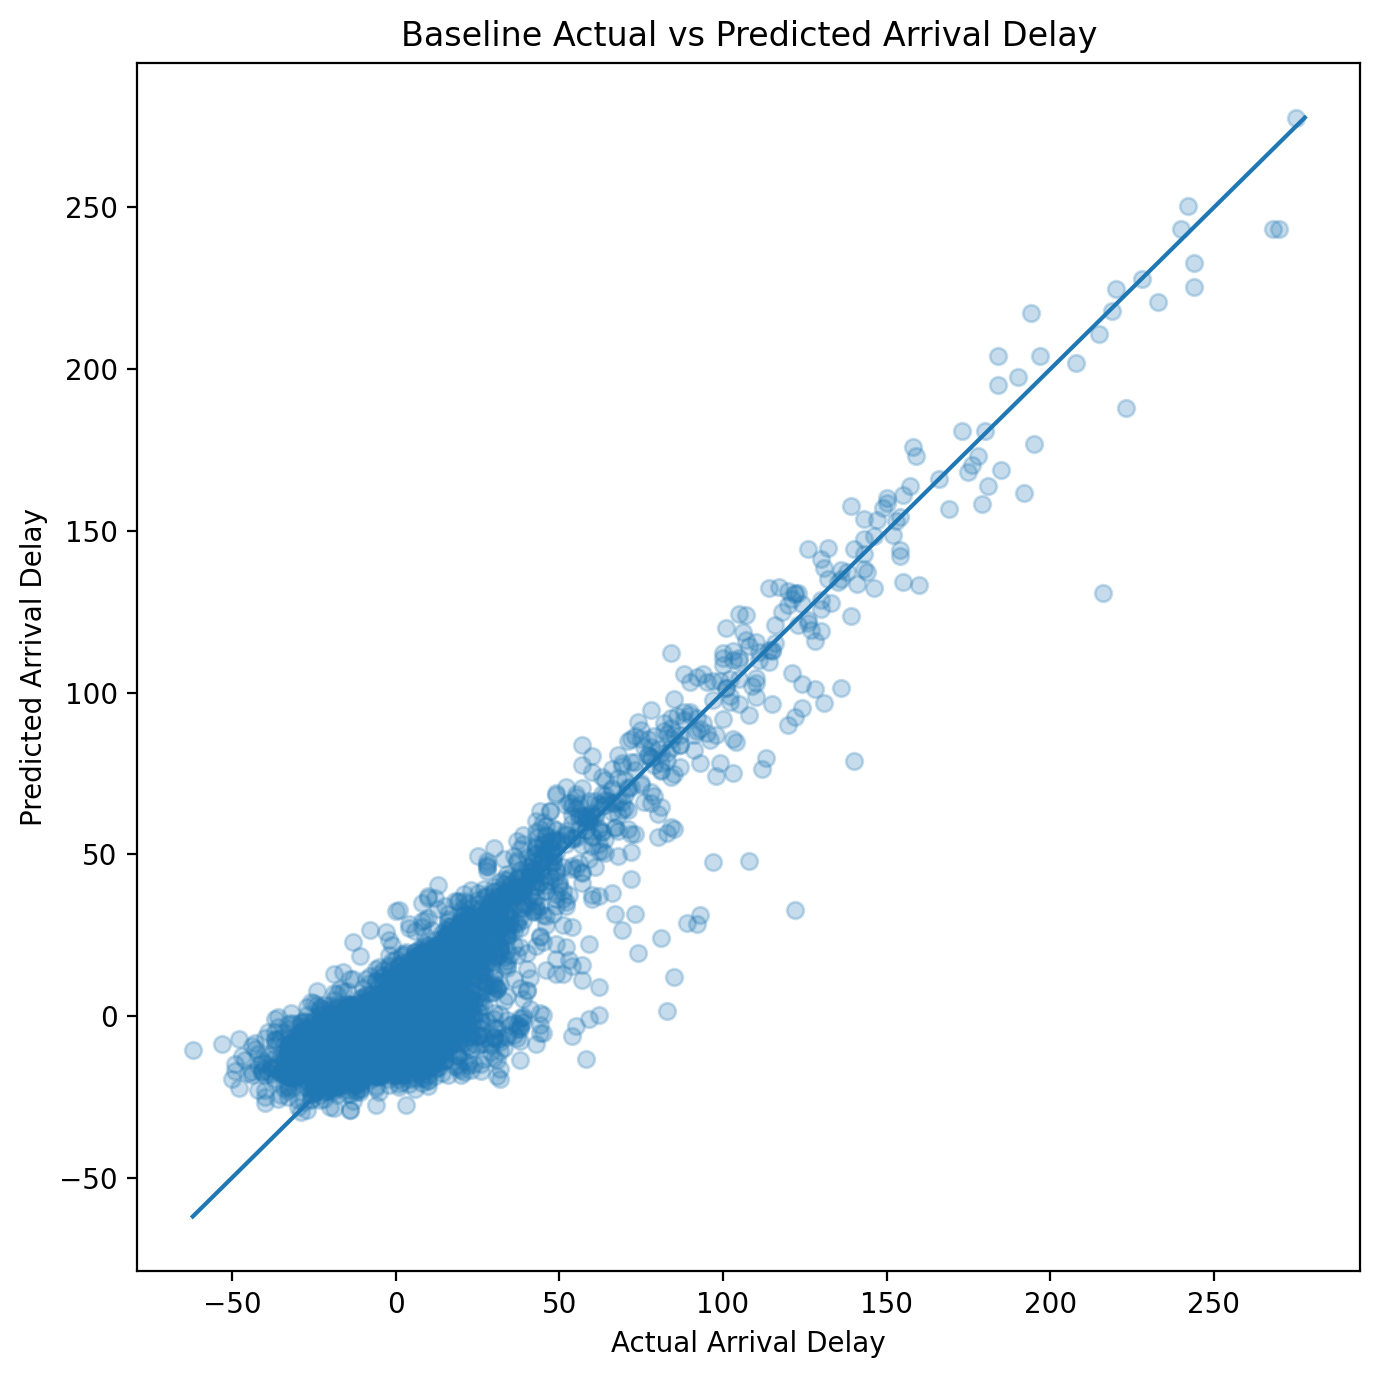

Random Forest


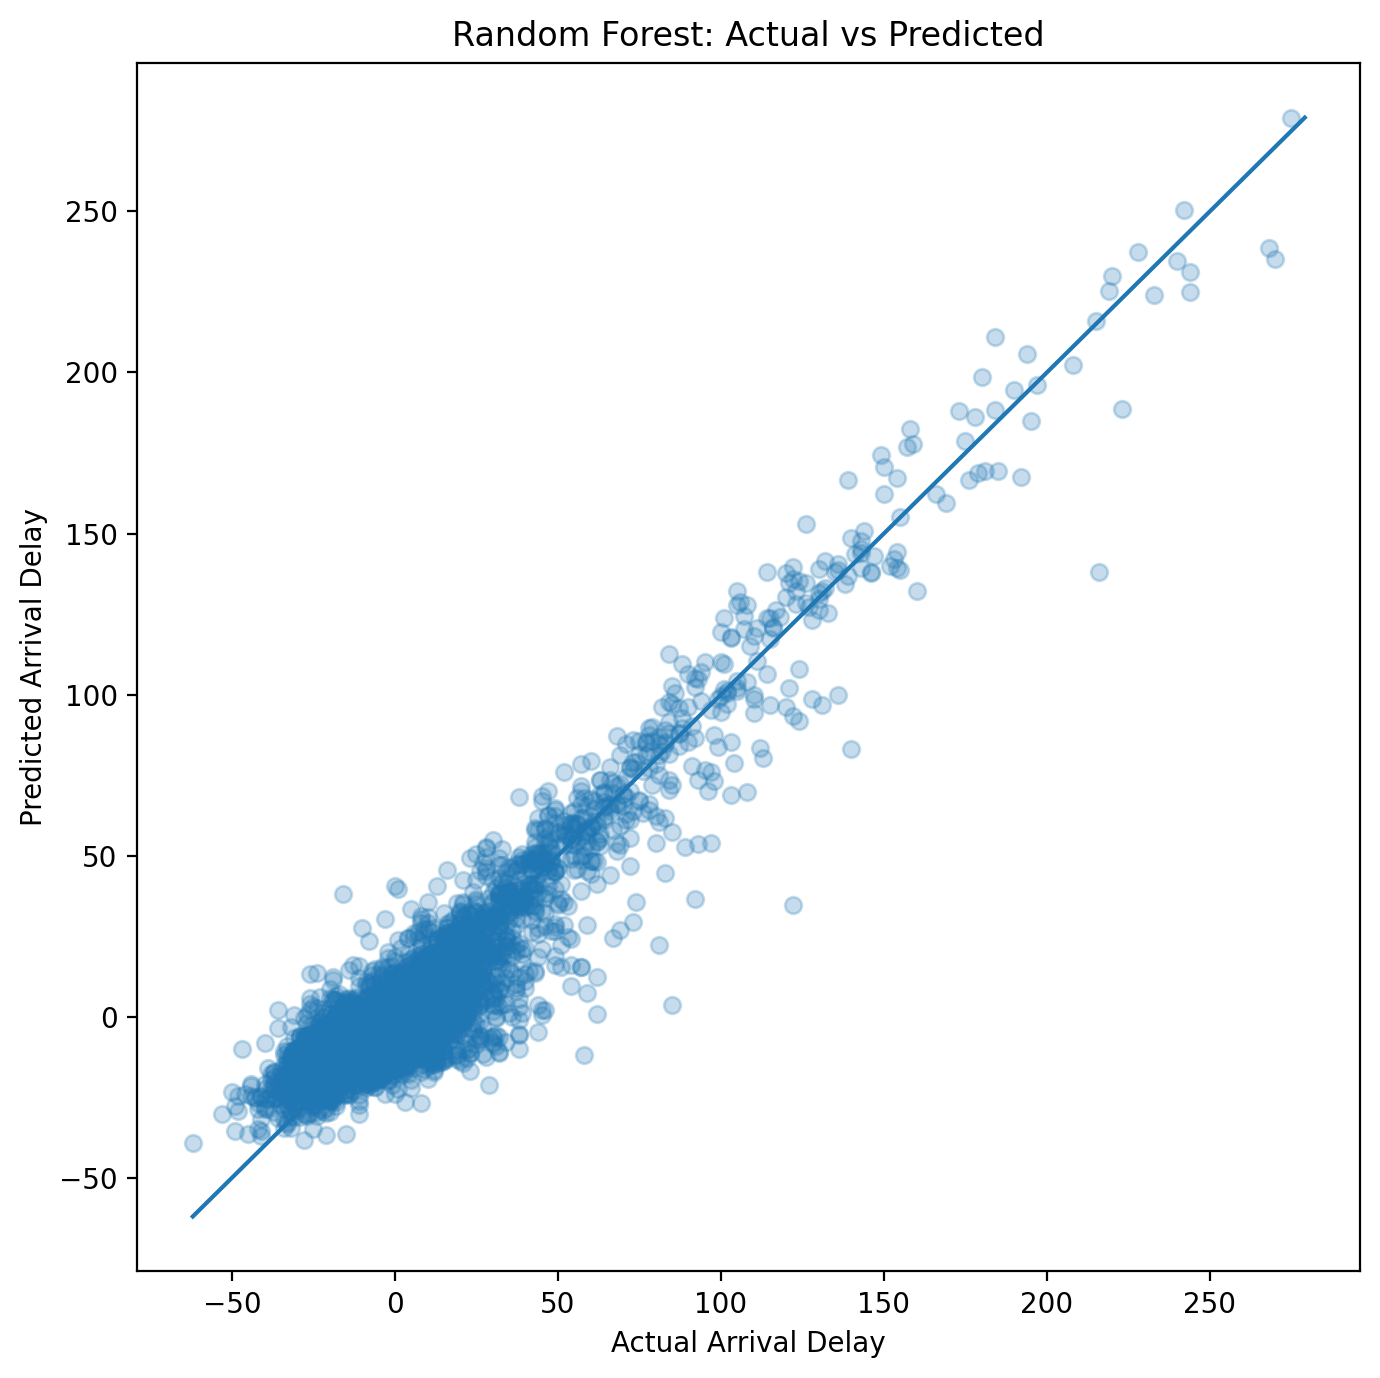

XGBoost


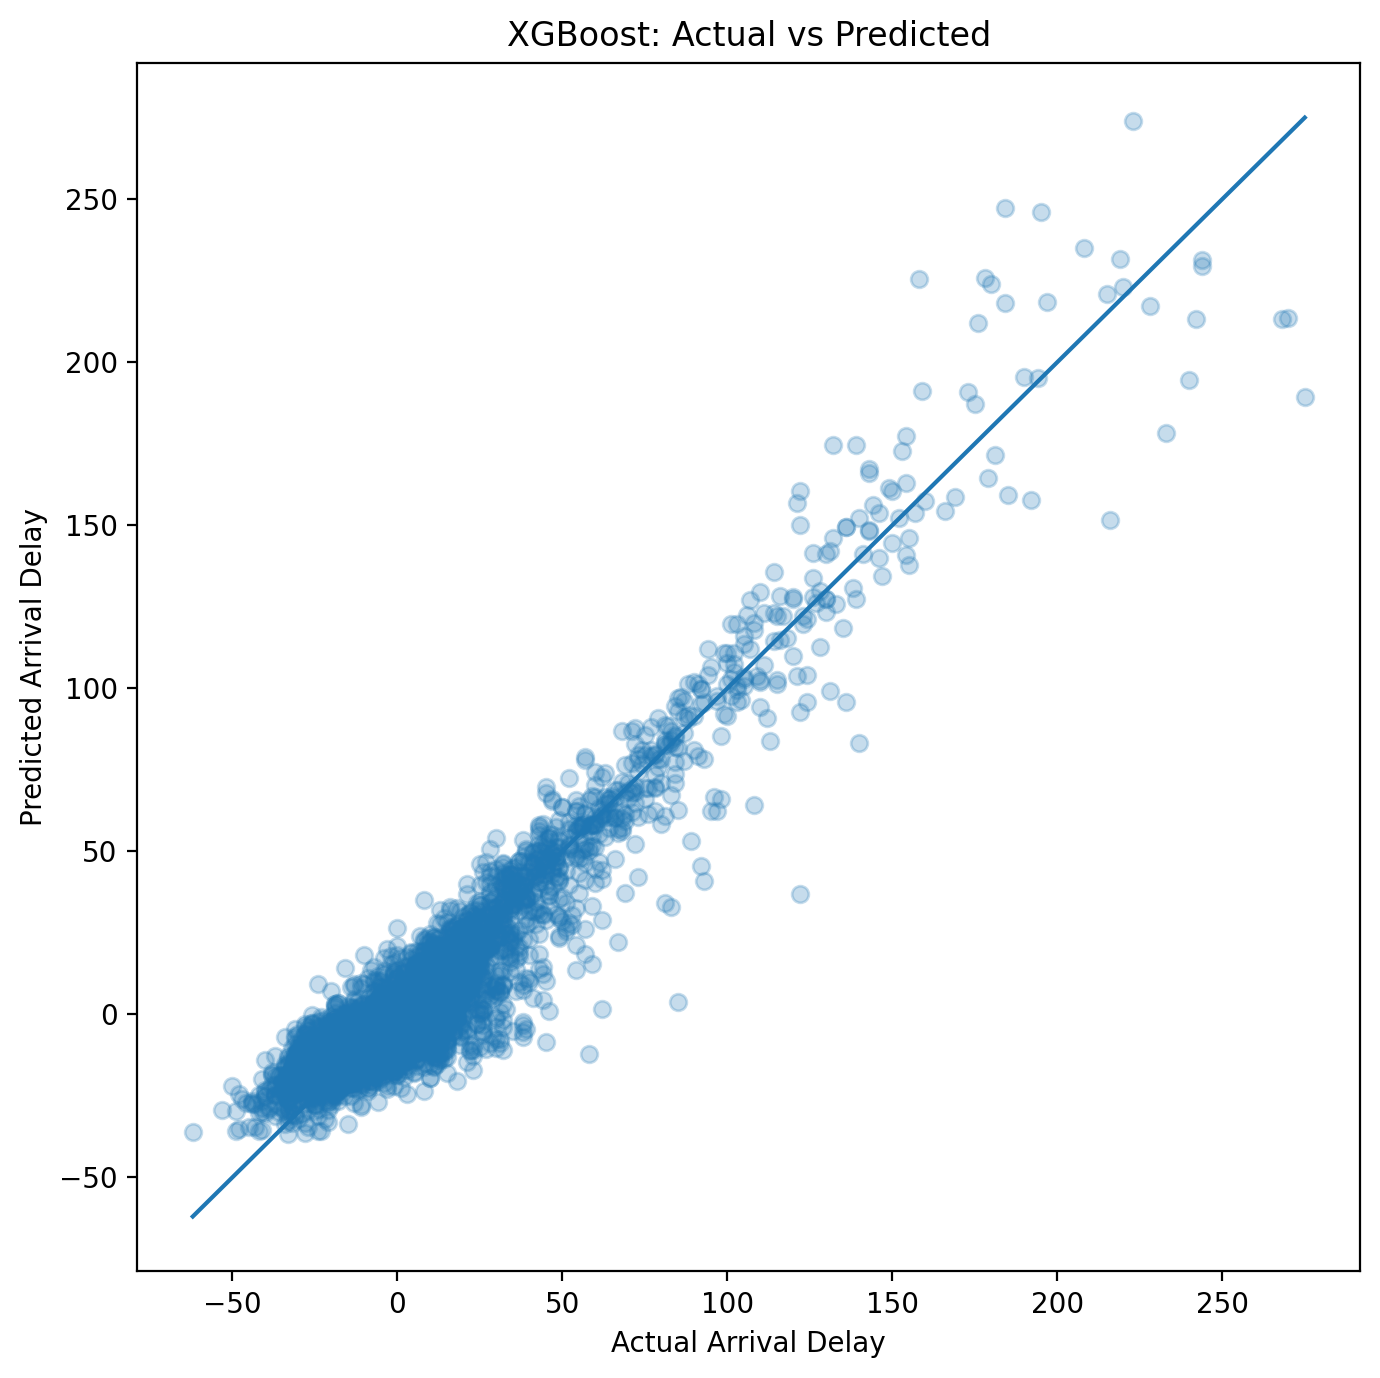

In [39]:
baseline_plot = RESULTS_DIR / "model_outputs" / "baseline_actual_vs_predicted.png"
rf_plot = RESULTS_DIR / "model_outputs" / "rf_actual_vs_predicted.png"
xgb_plot = RESULTS_DIR / "model_outputs" / "xgb_actual_vs_predicted.png"

if baseline_plot.exists():
    print("Baseline")
    display(Image(filename=str(baseline_plot), width=500))

if rf_plot.exists():
    print("Random Forest")
    display(Image(filename=str(rf_plot), width=500))

if xgb_plot.exists():
    print("XGBoost")
    display(Image(filename=str(xgb_plot), width=500))

In [40]:
# AI generated:
metrics_files = [
    RESULTS_DIR / "model_outputs" / "baseline_metrics.txt",
    RESULTS_DIR / "model_outputs" / "rf_metrics.txt",
    RESULTS_DIR / "model_outputs" / "xgb_metrics.txt",
]

for path in metrics_files:
    print(path.name)
    print(path.read_text(encoding="utf-8"))
    print("-" * 60)

baseline_metrics.txt
Baseline Model Metrics
MAE : 8.3143
RMSE: 11.4414
R^2 : 0.8427

Interpretation:
- MAE is the average absolute prediction error in minutes.
- RMSE penalizes larger errors more heavily.
- R^2 measures how much variance is explained by the model.
------------------------------------------------------------
rf_metrics.txt
Random Forest Metrics

MAE  : 7.4645
RMSE : 10.2658
R^2  : 0.8734

------------------------------------------------------------
xgb_metrics.txt
XGBoost Metrics

MAE  : 7.0416
RMSE : 9.8060
R^2  : 0.8844

------------------------------------------------------------


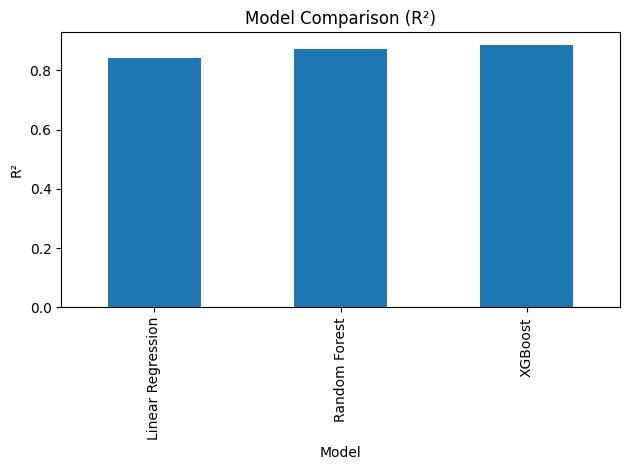

In [44]:
df_compare.plot(x="Model", y="R2", kind="bar", legend=False)
plt.title("Model Comparison (R²)")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

## 6. Comparison Summary

- Linear Regression is the baseline model.
- Random Forest improves over Linear Regression.
- XGBoost gives the best overall performance.
- Departure delay is the strongest predictor of arrival delay.
